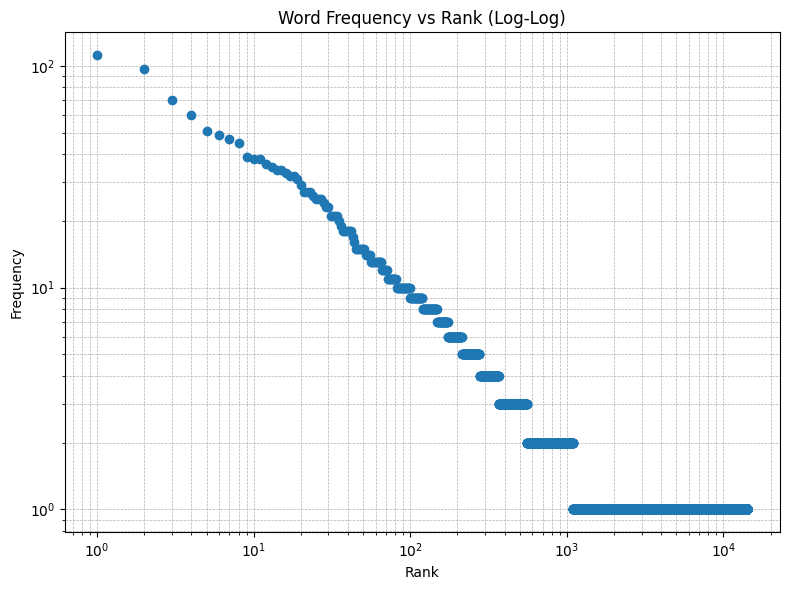

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import re

# ファイル読み込み
with open("kokoro.txt", encoding="utf-8") as f:
    text = f.read()

# 単語抽出（日本語処理では厳密な分かち書きが必要だが、ここでは単純な文字列抽出）
words = re.findall(r'\w+', text)

# 頻度カウント
counter = Counter(words)

# 頻度順に並べ替え
freqs = sorted(counter.values(), reverse=True)

# ランク（順位）と頻度を取得
ranks = np.arange(1, len(freqs) + 1)
frequencies = np.array(freqs)

# 両対数グラフでプロット
plt.figure(figsize=(8, 6))
plt.loglog(ranks, frequencies, marker="o", linestyle="none")
plt.title("Word Frequency vs Rank (Log-Log)")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


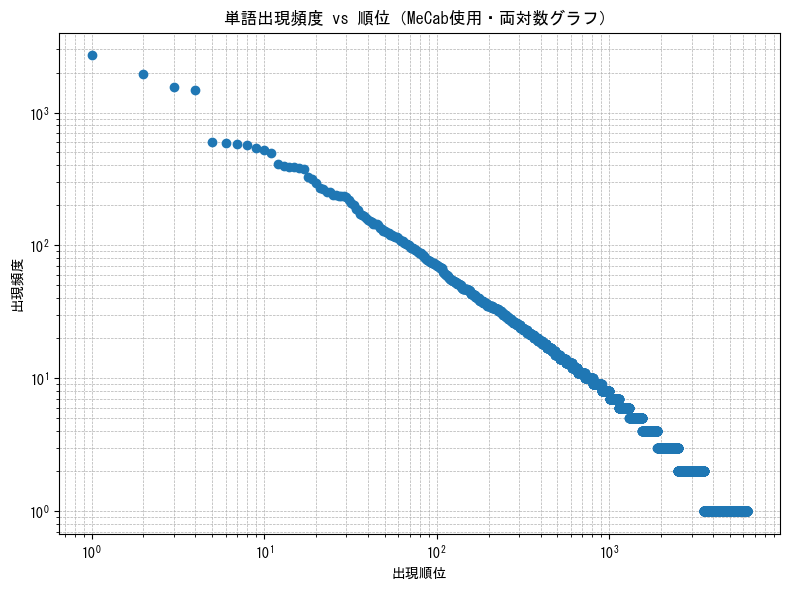

In [ ]:
import MeCab
import ipadic
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# 日本語フォント設定
plt.rcParams['font.family'] = "MS Gothic"

# ファイル読み込み
with open("kokoro.txt", encoding="utf-8") as f:
    text = f.read()

# MeCabの初期化
# MeCabの辞書をipadicに設定
tagger = MeCab.Tagger(ipadic.MECAB_ARGS)

# 形態素解析
# 形態素解析を行い、名詞、動詞、形容詞、副詞を抽出
# 形態素解析の結果をノードとして取得
node = tagger.parseToNode(text)
lemmas = []

# ノードをたどりながら、必要な品詞を抽出
# 名詞、動詞、形容詞、副詞を抽出
while node:
    features = node.feature.split(",")
    if features[0] == "名詞" or features[0] == "動詞" or features[0] == "形容詞" or features[0] == "副詞":
        # 基本形を取得
        if features[6] != "*":
            lemma = features[6]
        # 基本形がない場合は表層形を使用
        else:
            lemma = node.surface
        lemmas.append(lemma)
    node = node.next

# 頻度カウント
counter = Counter(lemmas)
# 頻度順に並べ替え
# 頻度を降順にソート
freqs = sorted(counter.values(), reverse=True)

# ランクと頻度を取得
ranks = np.arange(1, len(freqs) + 1)
# 頻度をNumPy配列に変換
frequencies = np.array(freqs)

# 両対数グラフ
plt.figure(figsize=(8, 6))
plt.loglog(ranks, frequencies, marker="o", linestyle="none")
plt.title("単語出現頻度 vs 順位（MeCab使用・両対数グラフ）")
plt.xlabel("出現順位")
plt.ylabel("出現頻度")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()
